In [1]:
import pandas as pd
import pandas_ta as ta
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display as dp
import os

In [2]:
tickers = ['엔비디아', '알파벳', '애플']
paths = [
    '/home/nshawny/AI project 2/personal_data/stock/overseas/엔비디아_features.csv',
    '/home/nshawny/AI project 2/personal_data/stock/overseas/알파벳_features.csv',
    '/home/nshawny/AI project 2/personal_data/stock/overseas/애플_features.csv'
]

# zip으로 묶어서 dict로 만들기
stock_dict = {name: pd.read_csv(path) for name, path in zip(tickers, paths)}

# 확인
for name, df in stock_dict.items():
    print(f'{name}: {df.shape}')

엔비디아: (1255, 34)
알파벳: (1255, 34)
애플: (1255, 34)


In [4]:
from statsmodels.tsa.stattools import adfuller

# 정상성 검정 함수
def adf_test(series, name):
    result = adfuller(series.dropna())
    print(f'📌 {name} - ADF Test')
    print(f'   Statistic: {result[0]:.4f}')
    print(f'   p-value: {result[1]:.4f}')
    print('   Critical Values:')
    for key, value in result[4].items():
        print(f'     {key}: {value:.4f}')
    print('')

# 모든 종목에 대해 종가 컬럼을 대상으로 수행
for name, df in stock_dict.items():
    adf_test(df['Close'], name)


📌 엔비디아 - ADF Test
   Statistic: 0.5118
   p-value: 0.9852
   Critical Values:
     1%: -3.4357
     5%: -2.8639
     10%: -2.5680

📌 알파벳 - ADF Test
   Statistic: -1.5993
   p-value: 0.4839
   Critical Values:
     1%: -3.4356
     5%: -2.8639
     10%: -2.5680

📌 애플 - ADF Test
   Statistic: -2.0342
   p-value: 0.2718
   Critical Values:
     1%: -3.4356
     5%: -2.8638
     10%: -2.5680



# ✅ 정상성 검정 결과 요약

---

## 📌 원본 시계열 ADF Test 결과

| 종목    | ADF Statistic | p-value | 해석                             |
|-------|---------------|---------|--------------------------------|
| 엔비디아 | 0.5118        | 0.9852  | **비정상성** (단위근 존재)       |
| 알파벳   | -1.5993       | 0.4839  | **비정상성** (추세 랜덤워크 형태) |
| 애플    | -2.0342       | 0.2718  | **비정상성** (추세 성분 존재)    |

✅ **해석**  
- p-value가 0.05보다 크므로 **귀무가설(비정상성) 기각 실패**
- → 원본 시계열은 모두 **비정상성**
- **권장 처리**: 차분 필요 (1차 차분 시도)

---

In [5]:
for name, df in stock_dict.items():
    diff_series = df['Close'].diff().dropna()
    print(f'📌 {name} - 1차 차분 ADF Test')
    adf_test(diff_series, name)


📌 엔비디아 - 1차 차분 ADF Test
📌 엔비디아 - ADF Test
   Statistic: -7.4038
   p-value: 0.0000
   Critical Values:
     1%: -3.4357
     5%: -2.8639
     10%: -2.5680

📌 알파벳 - 1차 차분 ADF Test
📌 알파벳 - ADF Test
   Statistic: -19.7658
   p-value: 0.0000
   Critical Values:
     1%: -3.4356
     5%: -2.8639
     10%: -2.5680

📌 애플 - 1차 차분 ADF Test
📌 애플 - ADF Test
   Statistic: -21.0633
   p-value: 0.0000
   Critical Values:
     1%: -3.4356
     5%: -2.8639
     10%: -2.5680



---

## 📌 1차 차분 시계열 ADF Test 결과

| 종목    | ADF Statistic | p-value | 해석                          |
|-------|---------------|---------|-----------------------------|
| 엔비디아 | -7.4038       | 0.0000  | ✅ **정상성 확보 (1차 차분)**  |
| 알파벳   | -19.7658      | 0.0000  | ✅ **정상성 확보 (1차 차분)**  |
| 애플    | -21.0633      | 0.0000  | ✅ **정상성 확보 (1차 차분)**  |

✅ **해석**  
- p-value가 0.05보다 작으므로 **귀무가설 기각**
- → 1차 차분 후 시계열은 **정상성 확보**
- ARIMA 모델링 가능 상태

---

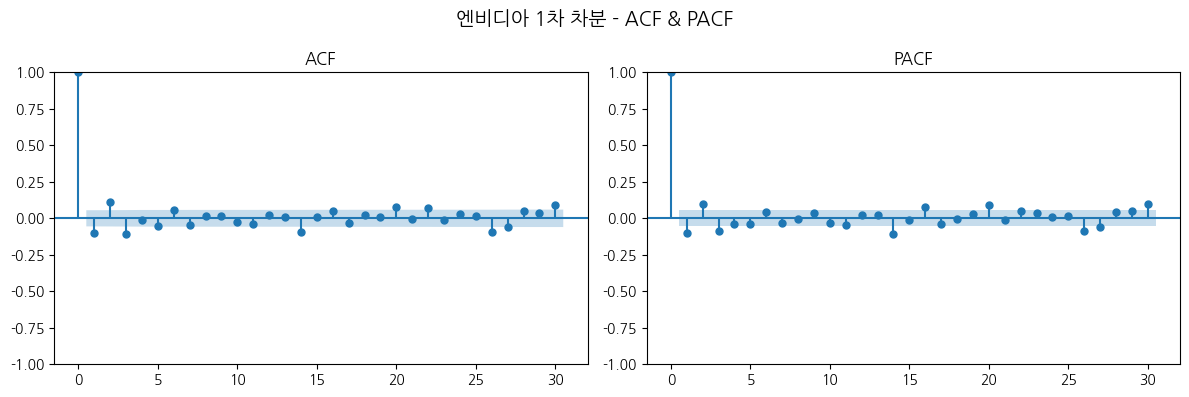

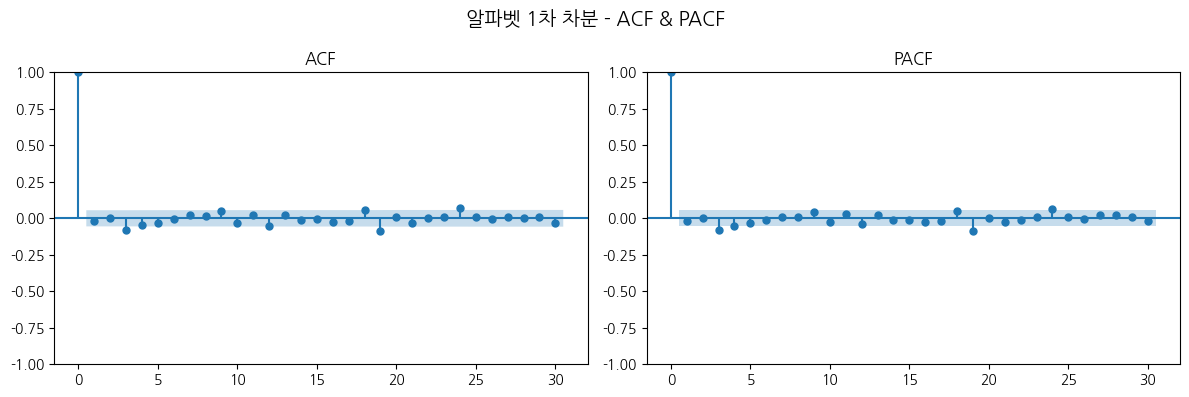

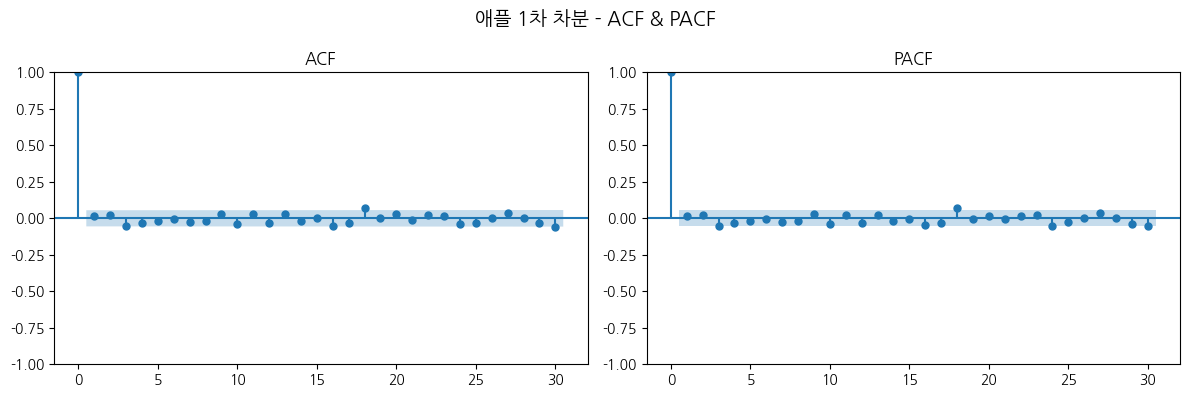

In [7]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt
import matplotlib

# 나눔고딕 설치되어 있으면 이렇게
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 깨짐 방지

for name, df in stock_dict.items():
    diff_series = df['Close'].diff().dropna()
    
    plt.figure(figsize=(12, 4))
    plt.suptitle(f'{name} 1차 차분 - ACF & PACF', fontsize=14)
    
    # ACF
    plt.subplot(1, 2, 1)
    plot_acf(diff_series, ax=plt.gca(), lags=30)
    plt.title('ACF')
    
    # PACF
    plt.subplot(1, 2, 2)
    plot_pacf(diff_series, ax=plt.gca(), lags=30, method='ywm')
    plt.title('PACF')
    
    plt.tight_layout()
    plt.show()

# ✅ ACF / PACF 분석 결과 요약

---

## 📌 종목별 ACF / PACF 플롯 해석

- **1차 차분 시계열 기준**
- 모든 종목에서 공통적으로 **계절성 신호 없음**
- ACF/PACF가 lag=0 이후 급격히 감소 → **랜덤워크적 성격 제거됨**
- 추가 AR, MA 차수가 필요해도 매우 낮은 차수 예상 (ARIMA(p=0~1, q=0~1) 수준 후보)

---

## ✅ 종목별 간단 해석

| 종목    | ACF 분석               | PACF 분석             | 시사점                             |
|-------|---------------------|--------------------|---------------------------------|
| 엔비디아 | lag 0 제외 급속 소멸  | lag 0 제외 급속 소멸 | 단기 상관만 존재, 추가 차수 매우 낮음 예상 |
| 알파벳   | 동일                  | 동일                 | 동일                              |
| 애플    | 동일                  | 동일                 | 동일                              |

---

✅ **결론**
- 1차 차분 후 정상성 확보 확인
- 추가 계절성 없음 → SARIMA 계절 차수 설정 필요 없음
- 딥러닝 입력 특성상 → 차분값 사용 시 추가 계절성 고려 불필요
- ARIMA 류 모델 → (p,d,q)에서 d=1 확정, p/q는 0~1 정도 후보
